In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from concurrent.futures import ThreadPoolExecutor
from datetime import date

import cma
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import root_mean_squared_error

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import kge, mkge, nse, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.parameters_running_jablje import (
    jablje_curve_number,
    jablje_groundwater,
    jablje_initial_cond,
    jablje_maize_params,
    jablje_management,
    jablje_readily_evaporable_water,
    jablje_soil_layers,
)
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison
from aquacrop_slovenia.reading_data import (
    get_co2_for_aquacrop,
    get_station_weather,
    get_yield,
    get_yield_for_comparison,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
K_FOLDS = 5
N_REPEATS = 1
MAX_WORKERS = os.cpu_count()

ALL_YEARS = [y for y in range(1993, 2024) if y != 2017]
print(f"Total years: {len(ALL_YEARS)}  ({ALL_YEARS[0]}–{ALL_YEARS[-1]}, excluding 2017)")
print(f"Total folds to run: {K_FOLDS * N_REPEATS}")

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}
print(f"Observed grain years: {sorted(observed_grain['year'].tolist())}")

Total years: 30  (1993–2023, excluding 2017)
Total folds to run: 5
Observed grain years: [1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2018, 2019, 2020, 2021, 2022, 2023]


In [4]:
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"cmaes_jablje_kfold_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories ready: {MAX_WORKERS}")

Worker directories ready: 28


In [5]:
param_names = [
    "harvest_index",
    "gdd_emergence",
    "gdd_max_rooting",
    "gdd_senescence",
    "gdd_maturity",
    "gdd_flowering",
    "gdd_flowering_length",
    "gdd_hi_start",
    "max_canopy_cover",
    #"cgc_gdd",
    #"cdc_gdd",
    #"ksat",
    "min_rooting_depth",
    "max_rooting_depth",
    #"p_upper_senescence",
    #"p_upper_stomata"
]

bounds = [
    (0.46, 0.6),    # harvest_index
    (5, 40),        # gdd_emergence
    (700, 1000),    # gdd_max_rooting
    (700, 1000),    # gdd_senescence
    (900, 1200),    # gdd_maturity
    (480,  530),    # gdd_flowering
    (130,  170),    # gdd_flowering_length
    (300, 500),     # gdd_hi_start
    (0.85, 0.97),   # max_canopy_cover
    #(0.005, 0.03),  # cgc_gdd
    #(0.005, 0.02),  # cdc_gdd
    #(5, 1000),      # ksat
    (0.05, 0.4),     # min_rooting_depth
    (0.5, 2.5),     # max_rooting_depth
    #(0.4, 0.8),     # p_upper_senescence
    #(0.4, 0.8),     # p_upper_stomata
]

lower = np.array([b[0] for b in bounds])
upper = np.array([b[1] for b in bounds])
x0 = (lower + upper) / 2.0

def to_unit(x):
    return (np.asarray(x) - lower) / (upper - lower)

def from_unit(x_norm):
    return lower + np.asarray(x_norm) * (upper - lower)

print(f"Parameters: {param_names}")
print(f"x0:         {x0}")

Parameters: ['harvest_index', 'gdd_emergence', 'gdd_max_rooting', 'gdd_senescence', 'gdd_maturity', 'gdd_flowering', 'gdd_flowering_length', 'gdd_hi_start', 'max_canopy_cover', 'ksat', 'min_rooting_depth', 'max_rooting_depth']
x0:         [5.300e-01 2.250e+01 8.500e+02 8.500e+02 1.050e+03 5.050e+02 1.500e+02
 4.000e+02 9.100e-01 5.025e+02 2.250e-01 1.500e+00]


In [6]:
years_array = np.array(ALL_YEARS)

yield_series = observed_grain.set_index("year").loc[ALL_YEARS, "yield"]
yield_bins = pd.qcut(yield_series, q=K_FOLDS, labels=False).values

print("Yield quantile bins per year:")
for y, b, yld in zip(ALL_YEARS, yield_bins, yield_series):
    print(f"  {y}: {yld:.2f} t/ha → bin {b}")

kf = RepeatedStratifiedKFold(n_splits=K_FOLDS, n_repeats=N_REPEATS, random_state=42)

folds = []
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(years_array, yield_bins)):
    repeat  = fold_idx // K_FOLDS + 1
    split   = fold_idx  % K_FOLDS + 1
    train_years = years_array[train_idx].tolist()
    test_years  = years_array[test_idx].tolist()
    folds.append({"train": train_years, "test": test_years, "repeat": repeat, "split": split})

print(f"Total folds: {len(folds)}  ({N_REPEATS} repeats × {K_FOLDS} splits)")

Yield quantile bins per year:
  1993: 7.83 t/ha → bin 1
  1994: 10.42 t/ha → bin 3
  1995: 12.01 t/ha → bin 4
  1996: 8.27 t/ha → bin 1
  1997: 10.37 t/ha → bin 3
  1998: 8.89 t/ha → bin 1
  1999: 9.76 t/ha → bin 2
  2000: 10.13 t/ha → bin 2
  2001: 6.79 t/ha → bin 0
  2002: 12.08 t/ha → bin 4
  2003: 7.53 t/ha → bin 0
  2004: 6.11 t/ha → bin 0
  2005: 11.08 t/ha → bin 3
  2006: 7.82 t/ha → bin 1
  2007: 10.28 t/ha → bin 3
  2008: 9.15 t/ha → bin 2
  2009: 5.13 t/ha → bin 0
  2010: 7.48 t/ha → bin 0
  2011: 9.52 t/ha → bin 2
  2012: 10.64 t/ha → bin 3
  2013: 7.80 t/ha → bin 1
  2014: 10.29 t/ha → bin 3
  2015: 10.14 t/ha → bin 2
  2016: 9.37 t/ha → bin 2
  2018: 8.53 t/ha → bin 1
  2019: 12.00 t/ha → bin 4
  2020: 13.51 t/ha → bin 4
  2021: 11.08 t/ha → bin 4
  2022: 5.78 t/ha → bin 0
  2023: 12.65 t/ha → bin 4
Total folds: 5  (1 repeats × 5 splits)


In [7]:
def make_simulation_periods(years):
    return [
        {
            "start_date": date(y, 1, 1),
            "end_date":   date(y, 12, 31),
            "planting_date": date(y, 5, 3),
            "is_seeding_year": True,
        }
        for y in years
    ]


def evaluate_params(param_values, sim_periods):
    """Run one candidate on the given simulation periods and return grain metrics."""
    working_dir = dir_queue.get()
    try:
        crop_params = copy.deepcopy(jablje_maize_params)
        current_ksat = None

        for name, val in zip(param_names, param_values):
            if name == "ksat":
                current_ksat = float(val)
            else:
                crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        crop = Crop(
            name=f"{LOCATION} maize",
            description="cma-es-kfold",
            params=crop_params,
        )

        if current_ksat is not None:
            modified_layers = copy.deepcopy(jablje_soil_layers)
            for layer in modified_layers:
                layer.ksat = current_ksat
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=modified_layers,
                curve_number=jablje_curve_number,
                readily_evaporable_water=jablje_readily_evaporable_water,
            )
        else:
            current_soil = soil

        simulation = AquaCrop(
            simulation_periods=sim_periods,
            crop=crop,
            soil=current_soil,
            management=jablje_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_result = {"grain_rmse": np.nan, "grain_nse": np.nan, "grain_kge": np.nan, "grain_mkge": np.nan}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return nan_result

        seasonal = results["season"][["Year1", "Y(dry)"]].rename(
            columns={"Year1": "year", "Y(dry)": "grain_modeled"}
        )
        merged = observed_grain.merge(seasonal, on="year")
        if merged.empty:
            return nan_result

        y_obs = merged["yield"].values
        y_mod = merged["grain_modeled"].values
        return {
            "grain_rmse": root_mean_squared_error(y_obs, y_mod),
            "grain_nse":  nse(y_mod, y_obs),
            "grain_kge":  kge(y_mod, y_obs),
            "grain_mkge": mkge(y_mod, y_obs),
        }
    finally:
        dir_queue.put(working_dir)

In [8]:
SIGMA0 = 0.3
#default_popsize = 4 + int(3 * np.log(len(param_names)))
POPSIZE = MAX_WORKERS #max(MAX_WORKERS, default_popsize)

x0_norm = to_unit(x0)  # all 0.5 — optimizer works in [0, 1]^n

CMAES_OPTIONS = {
    "bounds": [[0.0] * len(param_names), [1.0] * len(param_names)],
    "popsize": POPSIZE,
    "maxiter": 30, # based on loss function convergence run for one fold
    "tolx": 1e-5,
    "tolfun": 1e-5,
    "seed": 42,
    "verbose": -9,   # suppress per-iteration output; fold progress printed manually
}

print(f"Cores: {MAX_WORKERS}  |  popsize: {POPSIZE}")

Cores: 28  |  popsize: 28


In [9]:
def run_fold(fold_idx, train_years, test_years, repeat, split):
    """Fit CMA-ES on train_years, evaluate on train and test. Returns a result dict."""
    train_periods = make_simulation_periods(train_years)
    test_periods  = make_simulation_periods(test_years)

    def objective(x_norm):
        r = evaluate_params(from_unit(x_norm), train_periods)
        return -r["grain_mkge"] if np.isfinite(r["grain_mkge"]) else 1e6

    def parallel_evaluate(solutions):
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
            return list(executor.map(objective, solutions))

    es = cma.CMAEvolutionStrategy(x0_norm, SIGMA0, CMAES_OPTIONS)
    convergence = []
    while not es.stop():
        solutions = es.ask()
        fitnesses = parallel_evaluate(solutions)
        penalty = max((f for f in fitnesses if np.isfinite(f)), default=1e6) * 10
        fitnesses = [penalty if not np.isfinite(f) else f for f in fitnesses]
        es.tell(solutions, fitnesses)
        convergence.append((es.result.iterations, es.result.fbest))

    xbest = from_unit(es.result.xbest)  # convert back to actual parameter values

    train_metrics = evaluate_params(xbest, train_periods)
    test_metrics  = evaluate_params(xbest, test_periods)

    total = K_FOLDS * N_REPEATS
    print(
        f"[{fold_idx+1}/{total}] repeat={repeat} split={split} — "
        f"train mkge={train_metrics['grain_mkge']:.4f}  "
        f"test mkge={test_metrics['grain_mkge']:.4f}  "
        f"(iters={es.result.iterations})"
    )

    return {
        "fold":        fold_idx + 1,
        "repeat":      repeat,
        "split":       split,
        "train_years": train_years,
        "test_years":  test_years,
        **{f"train_{k}": v for k, v in train_metrics.items()},
        **{f"test_{k}":  v for k, v in test_metrics.items()},
        **{f"best_{n}":  v for n, v in zip(param_names, xbest)},
        "iterations":  es.result.iterations,
        "evaluations": es.result.evaluations,
        "convergence": convergence,
    }

In [10]:
print(f"Running {N_REPEATS}×{K_FOLDS}-fold repeated stratified CV (objective: grain mKGE) …")
fold_results = []
for fold_idx, fold in enumerate(folds):
    print(f"Fold {fold_idx}", flush=True)
    result = run_fold(fold_idx, fold["train"], fold["test"], fold["repeat"], fold["split"])
    fold_results.append(result)

print("\nAll folds complete.")

Running 1×5-fold repeated stratified CV (objective: grain mKGE) …
Fold 0
AquaCrop simulation completed successfully
Parsing simulation results...
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


In [11]:
import pickle

pickle.dump(fold_results, open(config.RESULTS_DIR / "cmaes_jablje_kfold.pkl", "wb"))
print(f"Saved {len(fold_results)} fold results to {config.RESULTS_DIR / 'cmaes_jablje_kfold.pkl'}")

In [12]:
results_df = pd.DataFrame(fold_results)

metric_cols = ["train_grain_mkge", "train_grain_nse", "train_grain_rmse",
               "test_grain_mkge",  "test_grain_nse",  "test_grain_rmse"]

# Per-repeat summary: mean metric across the 5 splits within each repeat
repeat_summary = results_df.groupby("repeat")[metric_cols].mean().round(4)
print(f"Per-repeat mean metrics ({K_FOLDS} splits averaged):")
display(repeat_summary)

means = results_df[metric_cols].mean()
stds  = results_df[metric_cols].std()
print(f"\nOverall mean ± std across all {len(results_df)} folds ({N_REPEATS} repeats × {K_FOLDS} splits):")
for col in metric_cols:
    print(f"  {col}: {means[col]:.4f} ± {stds[col]:.4f}")

,train_grain_mkge,train_grain_nse,train_grain_rmse,test_grain_mkge,test_grain_nse,test_grain_rmse
repeat,,,,,,
1,0.6177,0.2251,1.7642,0.0874,-1.0173,2.4431


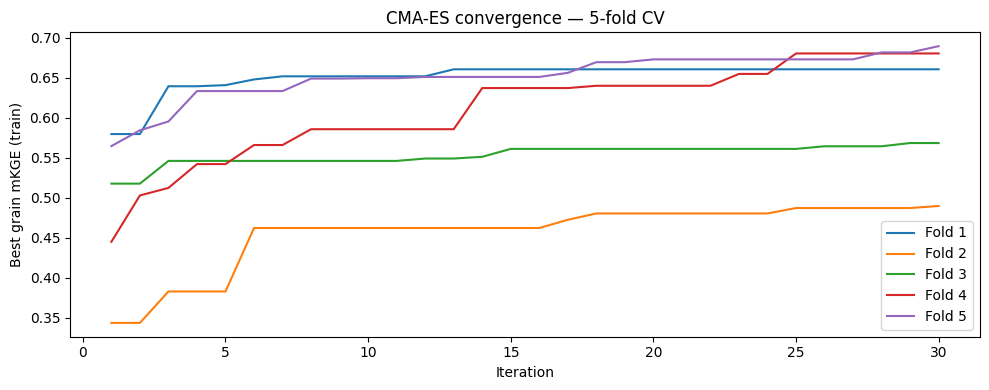

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

for result in fold_results:
    iters, fbest = zip(*result["convergence"])
    # fbest is -grain_mkge (CMA-ES minimises), convert back to mKGE
    mkge_best = [-f for f in fbest]
    ax.plot(iters, mkge_best, label=f"Fold {result['fold']}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Best grain mKGE (train)")
ax.set_title(f"CMA-ES convergence — {K_FOLDS}-fold CV")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
best_param_cols = [f"best_{n}" for n in param_names]
print("Best parameters per fold:")
display(results_df[best_param_cols].round(6))

print("\nMean best parameters:")
for col in best_param_cols:
    name = col.replace("best_", "")
    print(f"  {name}: {results_df[col].mean():.6f} ± {results_df[col].std():.6f}")

,best_harvest_index,best_gdd_emergence,best_gdd_max_rooting,best_gdd_senescence,best_gdd_maturity,best_gdd_flowering,best_gdd_flowering_length,best_gdd_hi_start,best_max_canopy_cover,best_ksat,best_min_rooting_depth,best_max_rooting_depth
0,0.465326,9.935151,769.296388,983.344762,1163.331840,480.907932,164.140578,394.192831,0.935526,719.604468,0.112939,0.500617
1,0.468361,13.730538,768.539778,996.286635,1193.981536,509.378869,146.975681,427.959804,0.918733,174.262934,0.058318,0.502329
2,0.464145,6.616414,740.132418,949.421643,1119.738894,500.433713,169.766771,350.553444,0.898950,113.790587,0.135314,0.500335
3,0.481086,35.869614,771.025726,982.195969,1185.129895,485.962536,167.986205,394.820123,0.969372,289.418344,0.089454,0.500030
4,0.568579,17.833115,794.029256,931.927545,1033.075473,522.337121,141.311114,351.663284,0.886043,998.809918,0.068809,0.510491


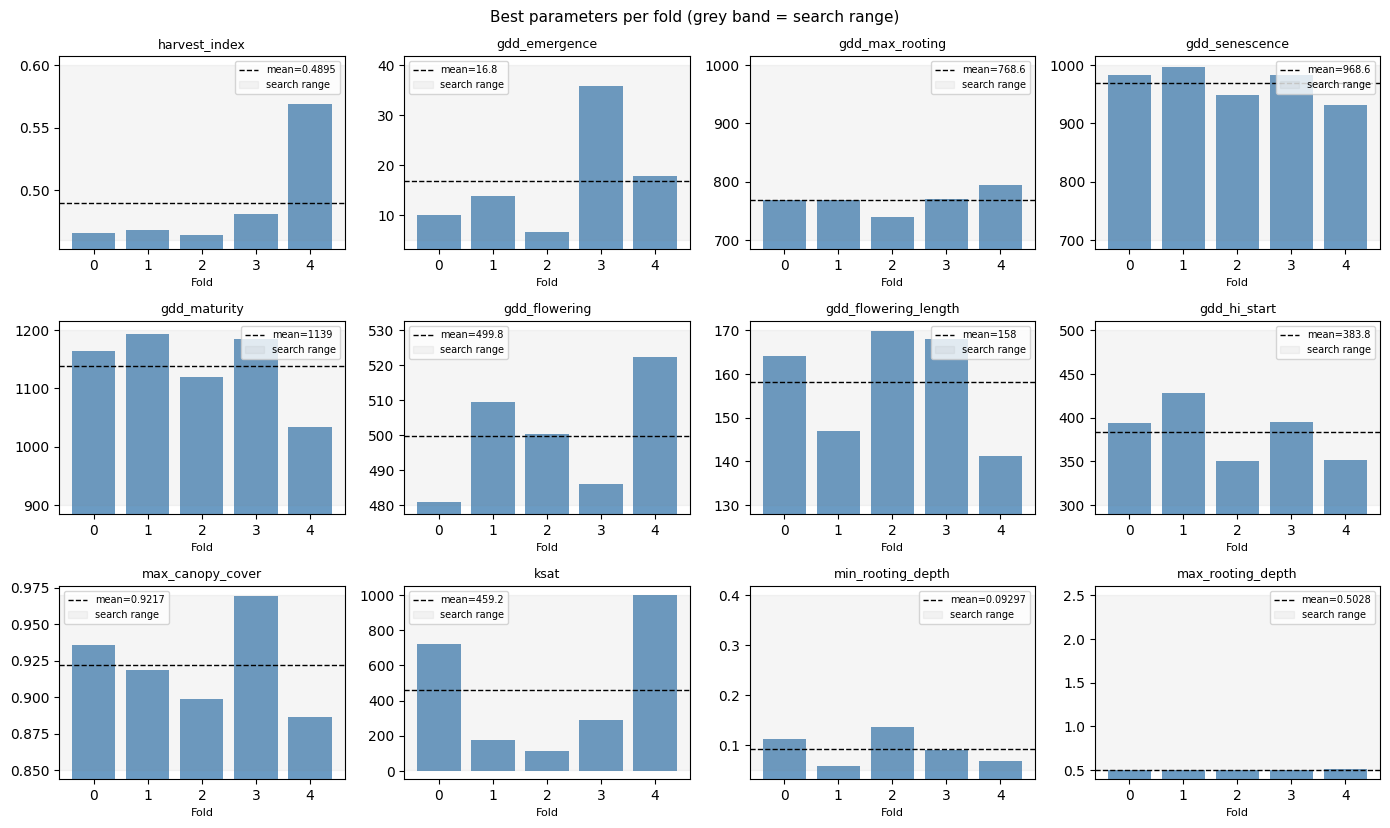

In [15]:
n_params = len(param_names)
ncols = 4
nrows = (n_params + ncols - 1) // ncols

bounds_dict = dict(zip(param_names, bounds))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
axes = axes.flatten()

for i, name in enumerate(param_names):
    col = f"best_{name}"
    vals = results_df[col]
    lo, hi = bounds_dict[name]

    ax = axes[i]
    ax.bar(results_df.index, vals, color="steelblue", alpha=0.8)
    ax.axhline(vals.mean(), color="black", linestyle="--", linewidth=1, label=f"mean={vals.mean():.4g}")
    ax.axhspan(lo, hi, color="grey", alpha=0.08, label="search range")
    ax.set_ylim(lo - 0.05 * (hi - lo), hi + 0.05 * (hi - lo))
    ax.set_title(name, fontsize=9)
    ax.set_xticks(results_df.index)
    ax.set_xlabel("Fold", fontsize=8)
    ax.legend(fontsize=7)

for j in range(n_params, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Best parameters per fold (grey band = search range)", fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
best_param_cols = [f"best_{n}" for n in param_names]
param_stats = pd.DataFrame({
    "lower_bound":  [lo for lo, hi in bounds],
    "upper_bound":  [hi for lo, hi in bounds],
    "mean":   results_df[best_param_cols].mean().values,
    "median": results_df[best_param_cols].median().values,
    "std":    results_df[best_param_cols].std().values,
}, index=param_names)
display(param_stats.round(6))

,lower_bound,upper_bound,mean,median,std
harvest_index,0.46,0.60,0.489499,0.468361,0.044717
gdd_emergence,5.00,40.00,16.796966,13.730538,11.456119
gdd_max_rooting,700.00,1000.00,768.604713,769.296388,19.127355
gdd_senescence,700.00,1000.00,968.635311,982.195969,26.839710
gdd_maturity,900.00,1200.00,1139.051527,1163.331840,65.829244
gdd_flowering,480.00,530.00,499.804034,500.433713,16.944496
gdd_flowering_length,130.00,170.00,158.036070,164.140578,12.999384
gdd_hi_start,300.00,500.00,383.837897,394.192831,32.854365
max_canopy_cover,0.85,0.97,0.921725,0.918733,0.032641
ksat,5.00,1000.00,459.177250,289.418344,383.507481


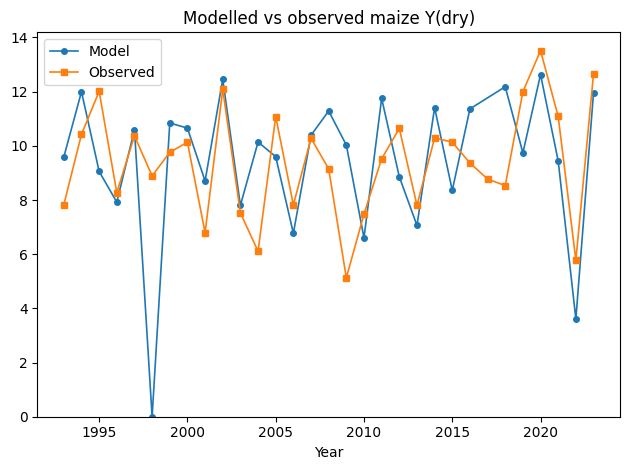

In [17]:
mean_params = param_stats["mean"].values

crop_params_avg = copy.deepcopy(jablje_maize_params)
avg_ksat = None
for name, val in zip(param_names, mean_params):
    if name == "ksat":
        avg_ksat = float(val)
    else:
        crop_params_avg[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if avg_ksat is not None:
    avg_layers = copy.deepcopy(jablje_soil_layers)
    for layer in avg_layers:
        layer.ksat = avg_ksat
    avg_soil = Soil(
        name=f"{LOCATION} soil",
        description="avg-params",
        soil_layers=avg_layers,
        curve_number=jablje_curve_number,
        readily_evaporable_water=jablje_readily_evaporable_water,
    )
else:
    avg_soil = soil

avg_dir = config.MODEL_RUNNING_DIR / "cmaes_jablje_kfold_avg"
avg_dir.mkdir(parents=True, exist_ok=True)

all_periods = make_simulation_periods(ALL_YEARS)
sim_avg = AquaCrop(
    simulation_periods=all_periods,
    crop=Crop(name=f"{LOCATION} maize", description="kfold-avg", params=crop_params_avg),
    soil=avg_soil,
    management=jablje_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    working_dir=avg_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)
with contextlib.redirect_stdout(io.StringIO()):
    seasonal_avg = sim_avg.run()["season"]

plot_yield_timeseries_comparison(seasonal_avg, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

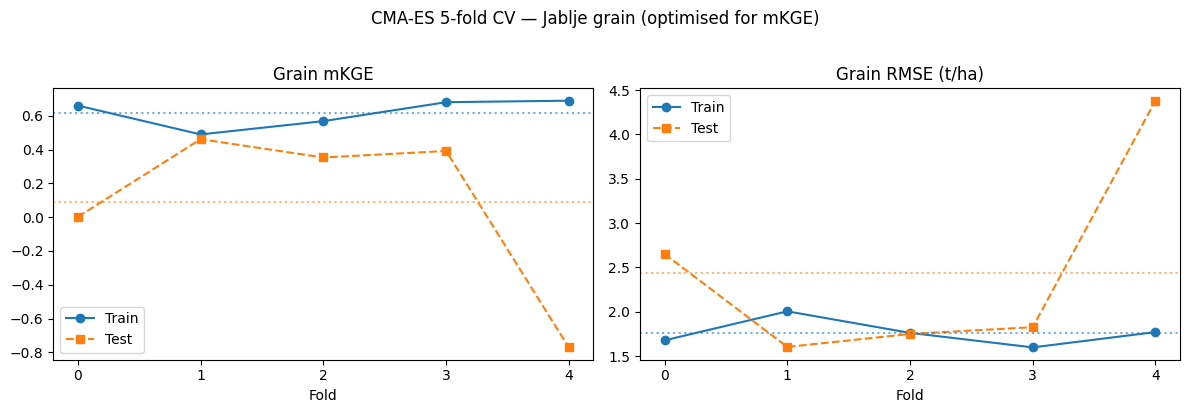

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, title in [
    (axes[0], "grain_mkge", "Grain mKGE"),
    (axes[1], "grain_rmse", "Grain RMSE (t/ha)"),
]:
    ax.plot(results_df.index, results_df[f"train_{metric}"], "o-", label="Train")
    ax.plot(results_df.index, results_df[f"test_{metric}"],  "s--", label="Test")
    ax.axhline(results_df[f"train_{metric}"].mean(), color="C0", linestyle=":", alpha=0.6)
    ax.axhline(results_df[f"test_{metric}"].mean(),  color="C1", linestyle=":", alpha=0.6)
    ax.set_xlabel("Fold")
    ax.set_title(title)
    ax.legend()
    ax.set_xticks(results_df.index)

fig.suptitle(f"CMA-ES {K_FOLDS}-fold CV — Jablje grain (optimised for mKGE)", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Re-run each fold's best params on its test years and collect predictions
all_predictions = []
for row in fold_results:
    xbest = [row[f"best_{n}"] for n in param_names]
    test_periods = make_simulation_periods(row["test_years"])

    crop_params = copy.deepcopy(jablje_maize_params)
    current_ksat = None
    for name, val in zip(param_names, xbest):
        if name == "ksat":
            current_ksat = float(val)
        else:
            crop_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

    if current_ksat is not None:
        modified_layers = copy.deepcopy(jablje_soil_layers)
        for layer in modified_layers:
            layer.ksat = current_ksat
        current_soil = Soil(
            name=f"{LOCATION} soil",
            description="kfold-pred",
            soil_layers=modified_layers,
            curve_number=jablje_curve_number,
            readily_evaporable_water=jablje_readily_evaporable_water,
        )
    else:
        current_soil = soil

    pred_dir = config.MODEL_RUNNING_DIR / f"cmaes_jablje_kfold_pred_{row['fold']}"
    pred_dir.mkdir(parents=True, exist_ok=True)

    sim = AquaCrop(
        simulation_periods=test_periods,
        crop=Crop(name=f"{LOCATION} maize", description="kfold-pred", params=crop_params),
        soil=current_soil,
        management=jablje_management,
        initial_conditions=jablje_initial_cond,
        climate=weather,
        working_dir=pred_dir,
        need_daily_output=False,
        need_seasonal_output=True,
        need_harvest_output=False,
        need_evaluation_output=False,
    )
    with contextlib.redirect_stdout(io.StringIO()):
        seasonal = sim.run()["season"][["Year1", "Y(dry)"]].rename(
            columns={"Year1": "year", "Y(dry)": "grain_modeled"}
        )
    seasonal["fold"] = row["fold"]
    all_predictions.append(seasonal)

pred_df = pd.concat(all_predictions).merge(observed_grain, on="year")
print(f"Predictions assembled: {len(pred_df)} years")
pred_df

,year,grain_modeled,fold,yield
0,1993,6.864,1,7.830
1,1994,7.255,1,10.422
2,1997,10.485,1,10.369
3,1999,10.857,1,9.760
4,2009,10.081,1,5.129
5,2019,9.654,1,11.998
6,2002,12.011,2,12.080
7,2005,9.864,2,11.081
8,2006,6.301,2,7.823
9,2007,10.301,2,10.278


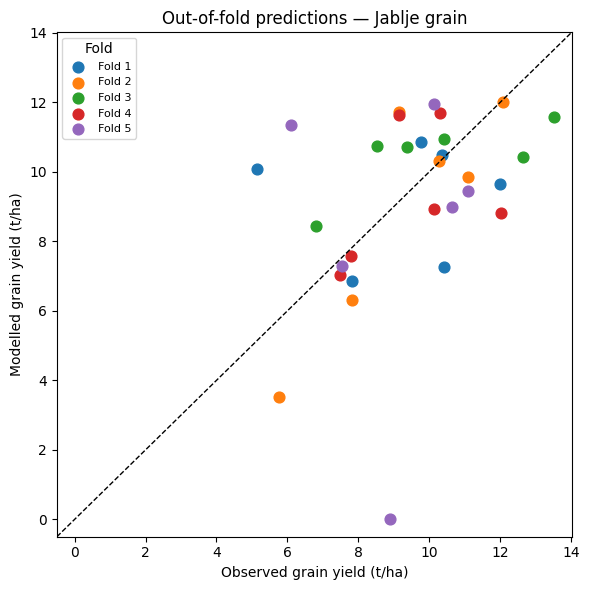

In [20]:
fig, ax = plt.subplots(figsize=(6, 6))

for fold_id, grp in pred_df.groupby("fold"):
    ax.scatter(grp["yield"], grp["grain_modeled"], label=f"Fold {fold_id}", s=60)

lim = [pred_df[["yield", "grain_modeled"]].min().min() - 0.5,
       pred_df[["yield", "grain_modeled"]].max().max() + 0.5]
ax.plot(lim, lim, "k--", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Observed grain yield (t/ha)")
ax.set_ylabel("Modelled grain yield (t/ha)")
ax.set_title("Out-of-fold predictions — Jablje grain")
ax.legend(title="Fold", fontsize=8)
plt.tight_layout()
plt.show()

overall_mkge = mkge(pred_df["grain_modeled"].values, pred_df["yield"].values)
overall_rmse = root_mean_squared_error(pred_df["yield"].values, pred_df["grain_modeled"].values)
print(f"Overall out-of-fold mKGE: {overall_mkge:.4f}")
print(f"Overall out-of-fold RMSE: {overall_rmse:.4f} t/ha")

## Weather statistics by fold

Checks how evenly the 5 sequential folds cover the weather distribution. Key concern: each test fold is a consecutive 6-year block, so climate trends (warmer/drier recent years) or single extreme seasons can make one fold systematically harder or easier.

In [21]:
# ── Load raw daily weather and compute annual / growing-season statistics ──────

weather_raw = pd.read_pickle(config.PROCESSED_WEATHER_DIR / "station_8.pkl")

# Assign dates (data starts 1993-01-01)
if not isinstance(weather_raw.index, pd.DatetimeIndex):
    weather_raw.index = pd.date_range("1993-01-01", periods=len(weather_raw), freq="D")

weather_raw["tmean"] = (weather_raw["tmin"] + weather_raw["tmax"]) / 2
weather_raw["gdd"]   = (weather_raw["tmean"] - 10).clip(lower=0)   # base 10 °C
weather_raw["year"]  = weather_raw.index.year
weather_raw["month"] = weather_raw.index.month

# Growing season May–Sep
gs = weather_raw[weather_raw["month"].between(5, 9)]

annual_stats = weather_raw.groupby("year").agg(
    annual_precip=("pad",   "sum"),
    annual_eto=   ("etp",   "sum"),
    annual_gdd=   ("gdd",   "sum"),
    annual_tmean= ("tmean", "mean"),
).round(1)

gs_stats = gs.groupby("year").agg(
    gs_precip=("pad",   "sum"),
    gs_eto=   ("etp",   "sum"),
    gs_gdd=   ("gdd",   "sum"),
    gs_tmax=  ("tmax",  "mean"),
    gs_tmean= ("tmean", "mean"),
    gs_tmin=  ("tmin",  "mean"),
).round(1)

stats = annual_stats.join(gs_stats)
stats["gs_water_deficit"] = (stats["gs_eto"] - stats["gs_precip"]).round(1)

# Restrict to modelled years and assign test-fold label from repeat 1 only
# (each year appears in test sets across all repeats; using repeat 1 gives
#  a clean 1–K_FOLDS split label for visualisation)
stats = stats.loc[stats.index.isin(ALL_YEARS)].copy()

year_to_fold = {}
for fold_info in folds:
    if fold_info["repeat"] == 1:
        for y in fold_info["test"]:
            year_to_fold[y] = fold_info["split"]
stats["fold"] = stats.index.map(year_to_fold)

# Merge observed yield
stats = stats.join(observed_grain.set_index("year").rename(columns={"yield": "obs_yield"}))

# Low-yield flag: below 25th percentile of observed yield
low_yield_thresh = stats["obs_yield"].quantile(0.25)
stats["low_yield"] = stats["obs_yield"] < low_yield_thresh
print(f"Low-yield threshold (25th pct): {low_yield_thresh:.2f} t/ha")
print(f"Low-yield years: {sorted(stats.index[stats['low_yield']].tolist())}")

display(stats.round(1))

C:\Users\rokku\AppData\Local\Temp\ipykernel_45116\1702234256.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  weather_raw["tmean"] = (weather_raw["tmin"] + weather_raw["tmax"]) / 2
C:\Users\rokku\AppData\Local\Temp\ipykernel_45116\1702234

,annual_precip,annual_eto,annual_gdd,annual_tmean,gs_precip,gs_eto,gs_gdd,gs_tmax,gs_tmean,gs_tmin,gs_water_deficit,fold,obs_yield,low_yield
year,,,,,,,,,,,,,,
1993,1180.9,760.6,1149.4,9.1,547.6,543.3,1040.2,23.5,16.8,10.1,-4.3,1,7.8,False
1994,1265.4,745.2,1220.2,10.3,675.3,533.9,1164.2,24.2,17.6,11.0,-141.4,3,10.4,False
1995,1436.3,695.6,1018.4,9.1,851.2,479.8,929.4,22.1,16.0,9.8,-371.4,4,12.0,False
1996,1439.8,644.8,995.6,8.3,687.5,475.5,924.1,21.9,16.0,10.2,-212.0,1,8.3,False
1997,1144.1,725.2,1104.4,9.2,529.1,517.6,1048.2,23.5,16.8,10.2,-11.5,1,10.4,False
1998,1347.8,709.7,1215.1,9.5,682.8,507.1,1136.8,23.8,17.4,11.0,-175.7,5,8.9,False
1999,1390.5,679.8,1241.6,9.3,712.3,495.2,1149.1,23.7,17.5,11.4,-217.1,1,9.8,False
2000,1439.3,747.8,1240.8,10.4,546.5,537.7,1078.8,24.1,17.0,10.0,-8.8,5,10.1,False
2001,1169.9,699.8,1173.8,9.6,504.4,508.3,1061.6,23.5,16.9,10.3,3.9,3,6.8,True


In [22]:

# ── Per-fold summary table ──────────────────────────────────────────────────────

summary_cols = {
    "annual_precip":    "Ann. precip (mm)",
    "gs_precip":        "GS precip (mm)",
    "gs_eto":           "GS ETo (mm)",
    "gs_water_deficit": "GS deficit (mm)",
    "gs_gdd":           "GS GDD (°C·d)",
    "gs_tmax":          "GS Tmax (°C)",
    "gs_tmean":         "GS Tmean (°C)",
    "gs_tmin":          "GS Tmin (°C)",
    "annual_tmean":     "Ann. Tmean (°C)",
    "obs_yield":        "Obs. yield (t/ha)",
}

fold_summary = (
    stats.groupby("fold")[list(summary_cols.keys())]
    .agg(["mean", "std"])
)
fold_summary.columns = [f"{summary_cols[col]} {agg}" for col, agg in fold_summary.columns]

# Also add low-yield count per fold
fold_summary["# low-yield years"] = stats.groupby("fold")["low_yield"].sum().astype(int)

print("Mean (± std) of weather statistics per test fold:")
display(fold_summary.round(1))

# Overall stats for reference
print("\nOverall (all modelled years):")
overall = stats[list(summary_cols.keys())].agg(["mean", "std"]).T
overall.columns = ["mean", "std"]
display(overall.round(1))


,Ann. precip (mm) mean,Ann. precip (mm) std,GS precip (mm) mean,GS precip (mm) std,GS ETo (mm) mean,GS ETo (mm) std,GS deficit (mm) mean,GS deficit (mm) std,GS GDD (°C·d) mean,GS GDD (°C·d) std,...,GS Tmax (°C) std,GS Tmean (°C) mean,GS Tmean (°C) std,GS Tmin (°C) mean,GS Tmin (°C) std,Ann. Tmean (°C) mean,Ann. Tmean (°C) std,Obs. yield (t/ha) mean,Obs. yield (t/ha) std,# low-yield years
fold,,,,,,,,,,,,,,,,,,,,,
1,1316.9,128.0,606.1,77.8,521.0,30.5,-85.1,103.1,1104.6,123.6,...,0.9,17.2,0.8,10.8,0.8,9.5,0.9,8.9,2.4,1
2,1166.9,203.3,649.2,163.3,533.3,41.0,-115.8,192.4,1173.7,124.8,...,1.1,17.6,0.8,10.8,0.8,9.9,0.8,9.4,2.3,2
3,1370.3,202.3,684.9,166.0,537.4,19.6,-147.5,159.3,1212.2,107.0,...,0.6,17.9,0.7,11.5,0.8,10.5,0.6,10.2,2.5,1
4,1492.0,267.1,745.6,113.5,523.9,29.4,-221.7,139.2,1130.0,124.6,...,1.0,17.4,0.8,11.2,0.8,10.0,0.8,9.5,1.7,2
5,1329.0,199.1,582.7,133.7,540.0,40.4,-42.7,170.8,1174.0,144.8,...,1.3,17.7,1.0,10.8,0.8,9.8,0.5,9.1,1.9,2


,mean,std
annual_precip,1335.0,217.8
gs_precip,653.7,138.4
gs_eto,531.1,31.7
gs_water_deficit,-122.6,157.3
gs_gdd,1158.9,122.7
gs_tmax,24.1,1.0
gs_tmean,17.5,0.8
gs_tmin,11.0,0.8
annual_tmean,9.9,0.8
obs_yield,9.4,2.1


C:\Users\rokku\AppData\Local\Temp\ipykernel_45116\1535503232.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_fold, labels=fold_labels, patch_artist=True, widths=0.5)
C:\Users\rokku\AppData\Local\Temp\ipykernel_45116\1535503232.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_fold, labels=fold_labels, patch_artist=True, widths=0.5)
C:\Users\rokku\AppData\Local\Temp\ipykernel_45116\1535503232.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_fold, labels=fold_labels, patch_artist=True, widths=0.5)
C:\Users\rokku\AppData\Local\Temp\ipyker

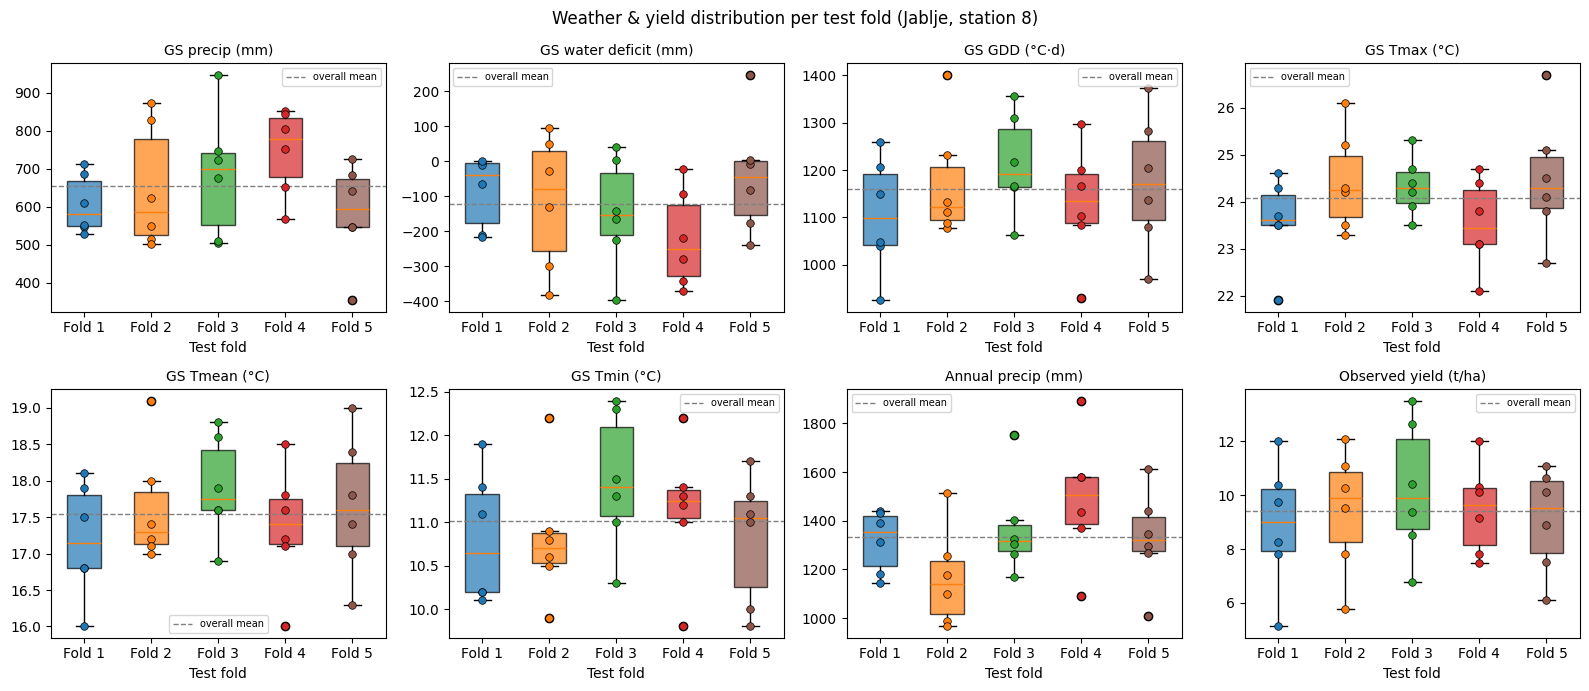

In [23]:
# ── Box plots: weather distribution per fold ────────────────────────────────────

plot_vars = [
    ("gs_precip",        "GS precip (mm)"),
    ("gs_water_deficit", "GS water deficit (mm)"),
    ("gs_gdd",           "GS GDD (°C·d)"),
    ("gs_tmax",          "GS Tmax (°C)"),
    ("gs_tmean",         "GS Tmean (°C)"),
    ("gs_tmin",          "GS Tmin (°C)"),
    ("annual_precip",    "Annual precip (mm)"),
    ("obs_yield",        "Observed yield (t/ha)"),
]

ncols = 4
nrows = (len(plot_vars) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
axes = axes.flatten()

fold_labels = [f"Fold {i}" for i in range(1, K_FOLDS + 1)]
colors = plt.cm.tab10(np.linspace(0, 0.5, K_FOLDS))

for ax, (col, label) in zip(axes, plot_vars):
    data_by_fold = [stats.loc[stats["fold"] == i, col].values for i in range(1, K_FOLDS + 1)]
    bp = ax.boxplot(data_by_fold, labels=fold_labels, patch_artist=True, widths=0.5)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    # Overlay individual points
    for j, (d, color) in enumerate(zip(data_by_fold, colors), start=1):
        ax.scatter([j] * len(d), d, color=color, zorder=3, s=30, edgecolors="k", linewidths=0.5)
    # Overall mean line
    ax.axhline(stats[col].mean(), color="grey", linestyle="--", linewidth=1, label="overall mean")
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Test fold")
    ax.legend(fontsize=7)

for j in range(len(plot_vars), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Weather & yield distribution per test fold (Jablje, station 8)", fontsize=12)
plt.tight_layout()
plt.show()


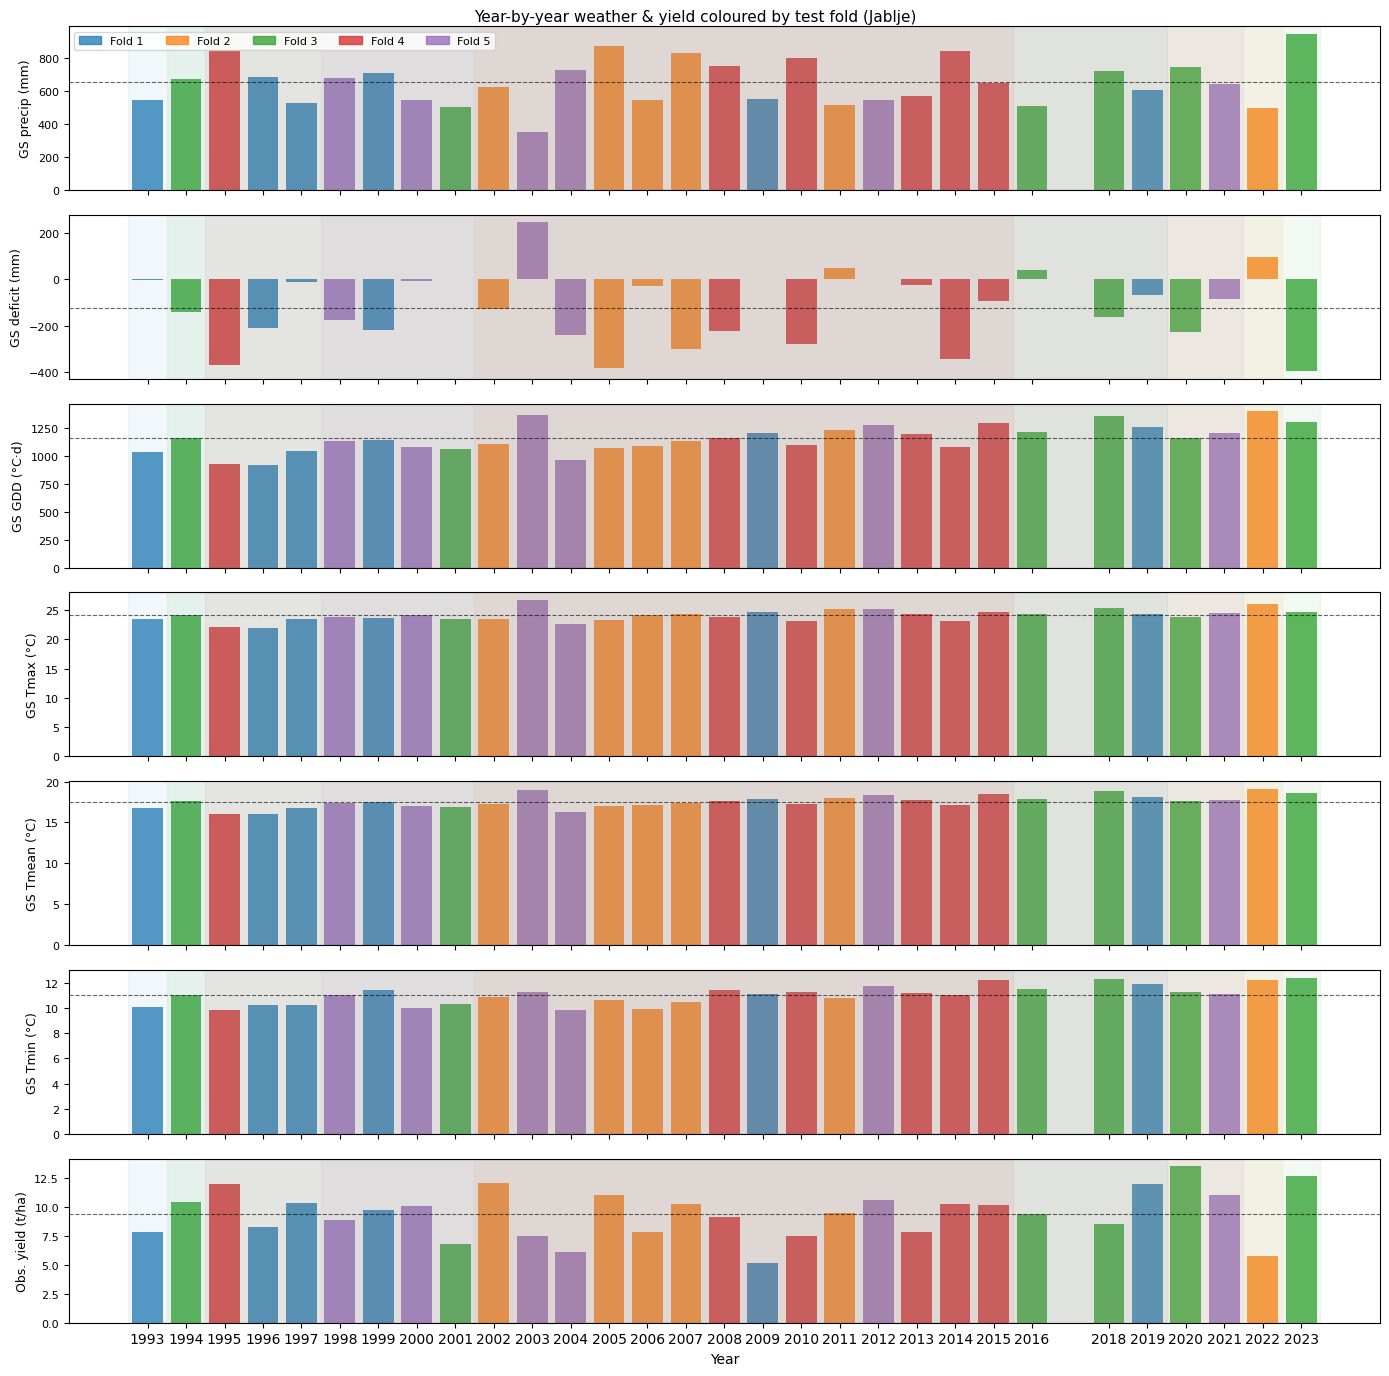

In [24]:
# ── Timeline heatmap: year × metric, coloured by fold ──────────────────────────

heatmap_cols = [
    ("gs_precip",        "GS precip (mm)"),
    ("gs_water_deficit", "GS deficit (mm)"),
    ("gs_gdd",           "GS GDD (°C·d)"),
    ("gs_tmax",          "GS Tmax (°C)"),
    ("gs_tmean",         "GS Tmean (°C)"),
    ("gs_tmin",          "GS Tmin (°C)"),
    ("obs_yield",        "Obs. yield (t/ha)"),
]

fold_colors_map = {1: "C0", 2: "C1", 3: "C2", 4: "C3", 5: "C4"}

fig, axes = plt.subplots(len(heatmap_cols), 1, figsize=(14, len(heatmap_cols) * 2.0), sharex=True)

for ax, (col, label) in zip(axes, heatmap_cols):
    for fold_id, grp in stats.groupby("fold"):
        ax.bar(grp.index, grp[col], color=fold_colors_map[fold_id],
               alpha=0.75, label=f"Fold {fold_id}", width=0.8)
    ax.axhline(stats[col].mean(), color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_ylabel(label, fontsize=9)
    ax.tick_params(axis="y", labelsize=8)

# Shade fold test bands
for ax in axes:
    for fold_id, fold_info in enumerate(folds, start=1):
        years = fold_info["test"]
        ax.axvspan(min(years) - 0.5, max(years) + 0.5, alpha=0.06,
                   color=fold_colors_map[fold_id])

axes[-1].set_xlabel("Year")

handles = [plt.Rectangle((0, 0), 1, 1, color=fold_colors_map[i], alpha=0.75) for i in range(1, K_FOLDS + 1)]
axes[0].legend(handles, [f"Fold {i}" for i in range(1, K_FOLDS + 1)],
               ncol=K_FOLDS, fontsize=8, loc="upper left")
axes[0].set_xticks(ALL_YEARS)
axes[0].set_xticklabels(ALL_YEARS, rotation=45, fontsize=7)

fig.suptitle("Year-by-year weather & yield coloured by test fold (Jablje)", fontsize=11)
plt.tight_layout()
plt.show()
